<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-bottom: 2px solid #333; padding-bottom: 12px; margin-bottom: 20px;">
    <h1 style="margin: 0 0 6px 0; font-size: 24px; color: #111;">air-quality-seasonal.ipynb</h1>
    <div style="font-size: 13px; color: #555;">
        <span><strong>Project:</strong> NYC Air Quality Public Health Data Analysis</span> &nbsp;&bull;&nbsp; 
        <span><strong>Author:</strong> Kathryn Penrod</span> &nbsp;&bull;&nbsp; 
        <span><strong>Goal:</strong> What seasonal or policy-driven variables influence spikes in health incidents?</span>
    </div>
</div>

In [2]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

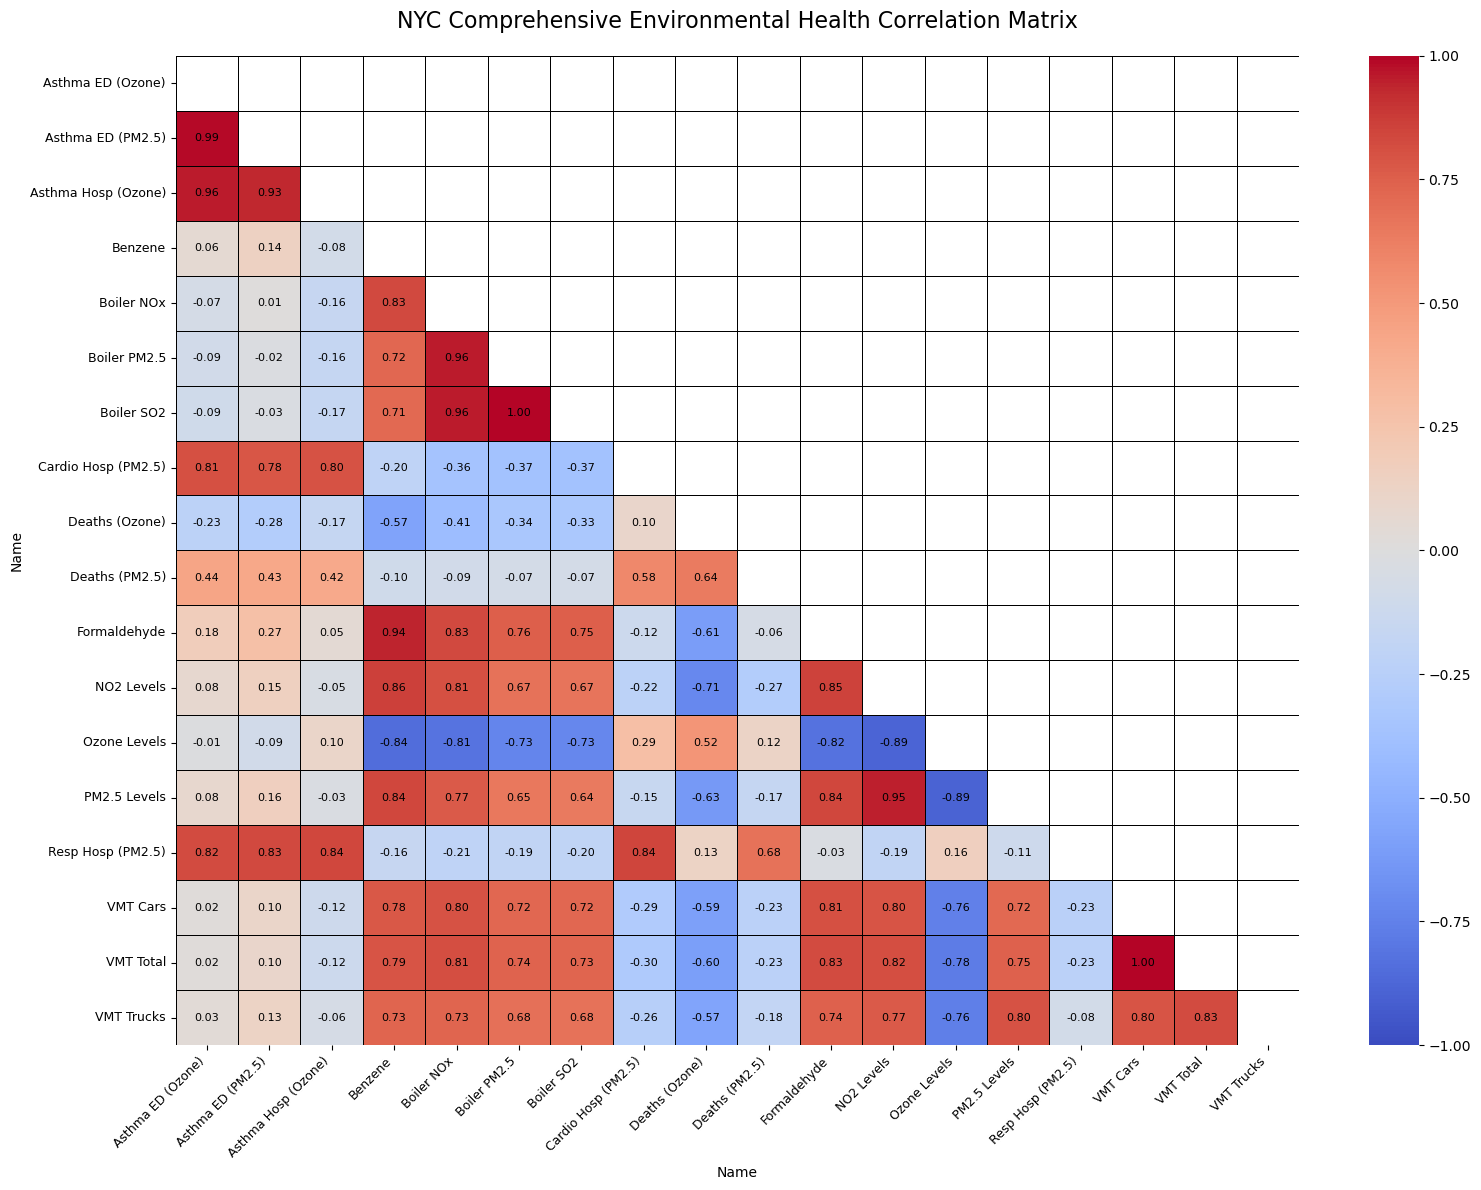

In [3]:
# Comprehensive Environmental Health Correlation Matrix


corr_matrix = pivoted_df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 12)) 
sns.heatmap( corr_matrix, mask=mask, cmap='coolwarm', linewidths=0.5, linecolor='black', cbar=True, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={'size': 8, 'color': 'black'} ) 
plt.xticks(rotation=45, ha='right', fontsize=9) 
plt.yticks(rotation=0, fontsize=9) 
plt.title('NYC Comprehensive Environmental Health Correlation Matrix', size=16, pad=20) 
plt.tight_layout() 
plt.show() 

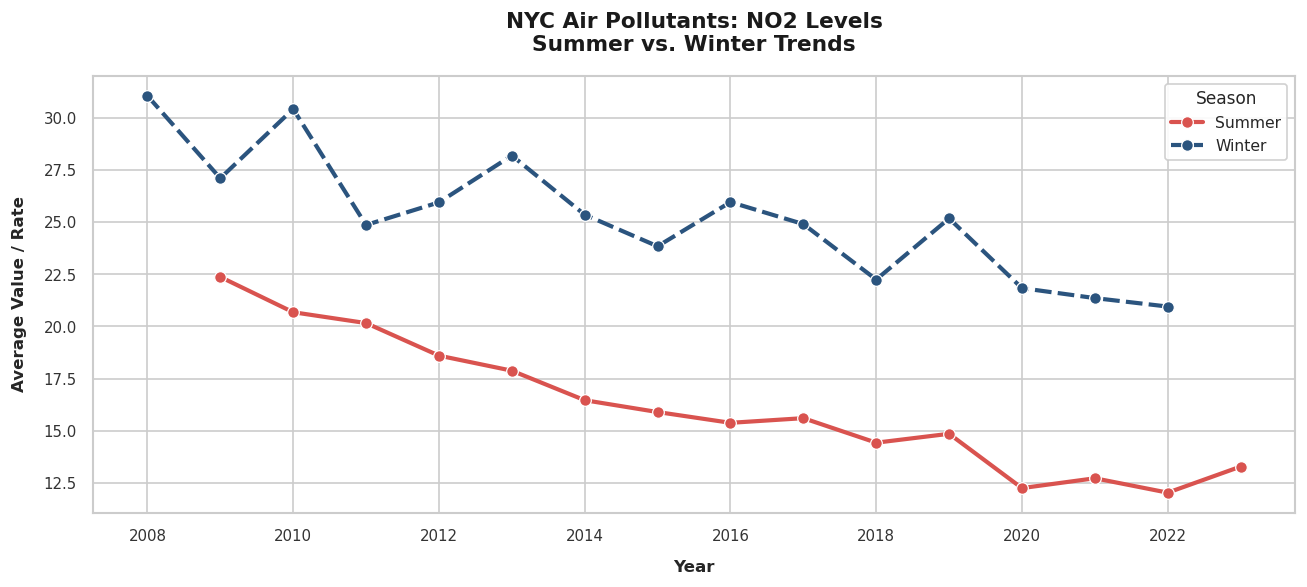

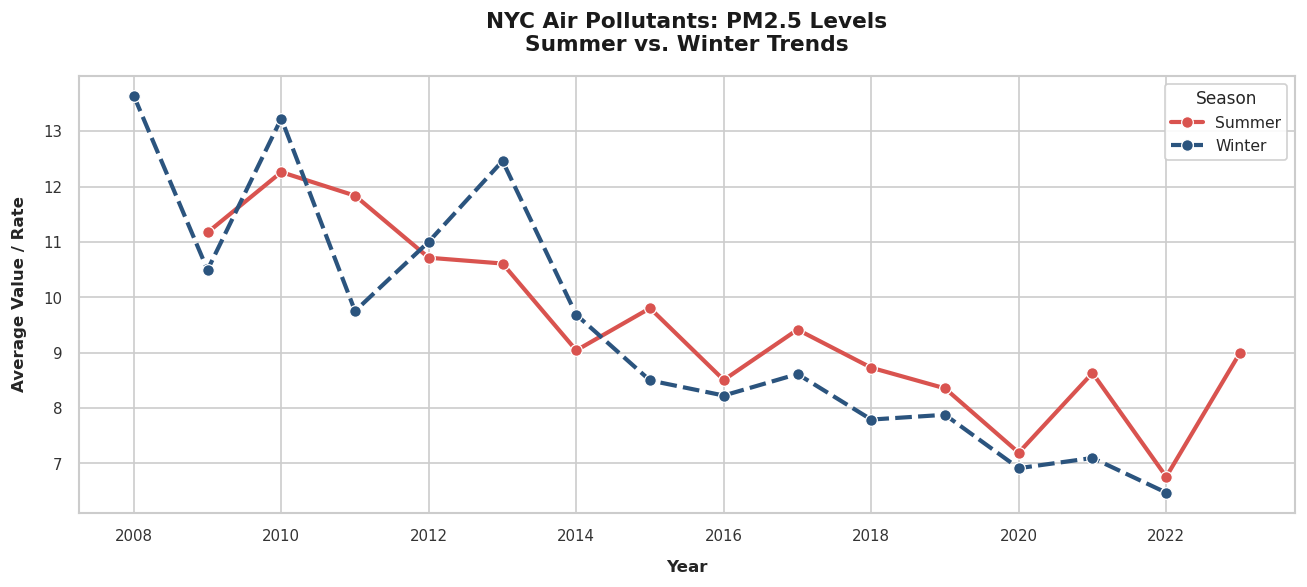

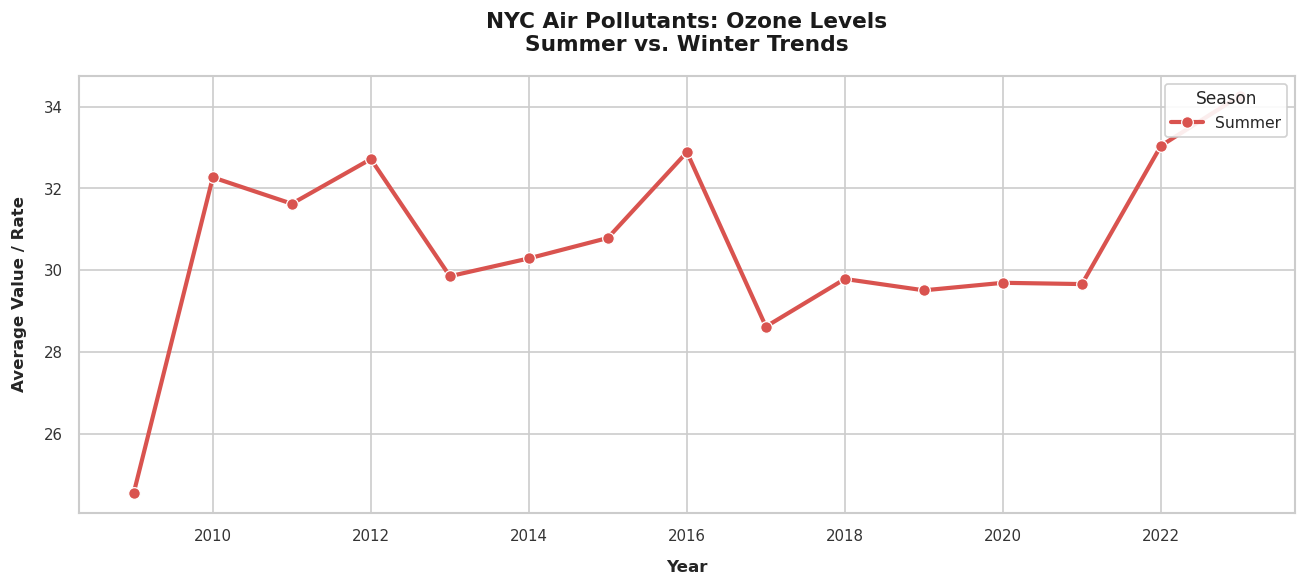

In [4]:
def extract_season_year(val):
  val_str = str(val)
  season = (
      "Summer"
      if "summer" in val_str.lower()
      else ("Winter" if "winter" in val_str.lower() else None)
  )
  match = re.search(r"\d{4}", val_str)
  year = int(match.group(0)) if match else None
  return season, year


# Get unique pollutants/metrics from the 'Name' column
pollutants = clean_df["Name"].unique()

for pollutant in pollutants:
  # Filter clean_df for the current pollutant
  sub_df = clean_df[clean_df["Name"] == pollutant].copy()

  # Filter rows containing Summer or Winter in 'Time Period'
  sub_df_filtered = sub_df[
      sub_df["Time Period"]
      .astype(str)
      .str.contains("Summer|Winter", case=False, na=False)
  ].copy()

  if sub_df_filtered.empty:
    continue

  parsed_data = []
  for _, row in sub_df_filtered.iterrows():
    s, y = extract_season_year(row["Time Period"])
    if s and y:
      parsed_data.append({"Year": y, "Season": s, "Value": row["Data Value"]})

  plot_df = pd.DataFrame(parsed_data)

  if not plot_df.empty:
    # Average duplicates and sort by year
    plot_df = plot_df.groupby(["Year", "Season"])["Value"].mean().reset_index()
    plot_df = plot_df.sort_values("Year")

    # Create your pivot chart named pivoted_df
    pivoted_df2 = plot_df.pivot(index="Year", columns="Season", values="Value")

    if not pivoted_df2.empty:
      plt.figure(figsize=(11, 5), dpi=120)
      sns.set_theme(style="whitegrid", font_scale=0.85)

      palette = {"Summer": "#D9534F", "Winter": "#2B547E"}

      ax = sns.lineplot(
          data=pivoted_df2,
          palette=palette,
          marker="o",
          linewidth=2.5,
          markersize=7,
      )

      # Fully labeled formatting restored
      plt.title(
          f"NYC Air Pollutants: {pollutant}\nSummer vs. Winter Trends",
          fontsize=13,
          fontweight="bold",
          pad=15,
          color="#1A1A1A",
          loc="center",
      )
      plt.xlabel("Year", fontsize=10, fontweight="bold", labelpad=10)
      plt.ylabel(
          "Average Value / Rate", fontsize=10, fontweight="bold", labelpad=10
      )

      plt.legend(
          title="Season",
          loc="upper right",
          frameon=True,
          facecolor="white",
          framealpha=0.9,
      )

      plt.xticks(fontsize=9, color="#333333")
      plt.yticks(fontsize=9, color="#333333")

      plt.tight_layout()
      plt.show()

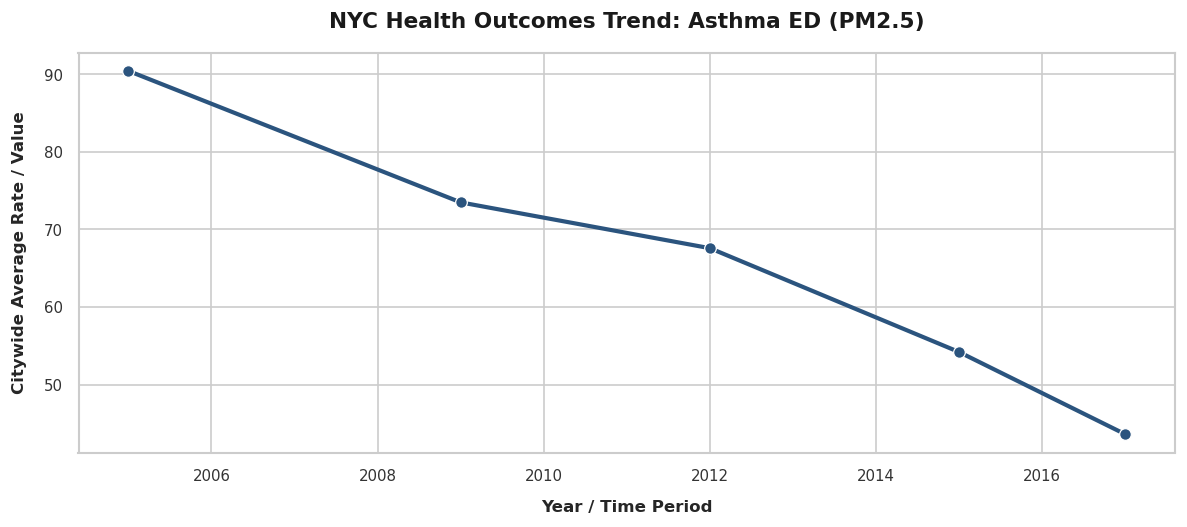

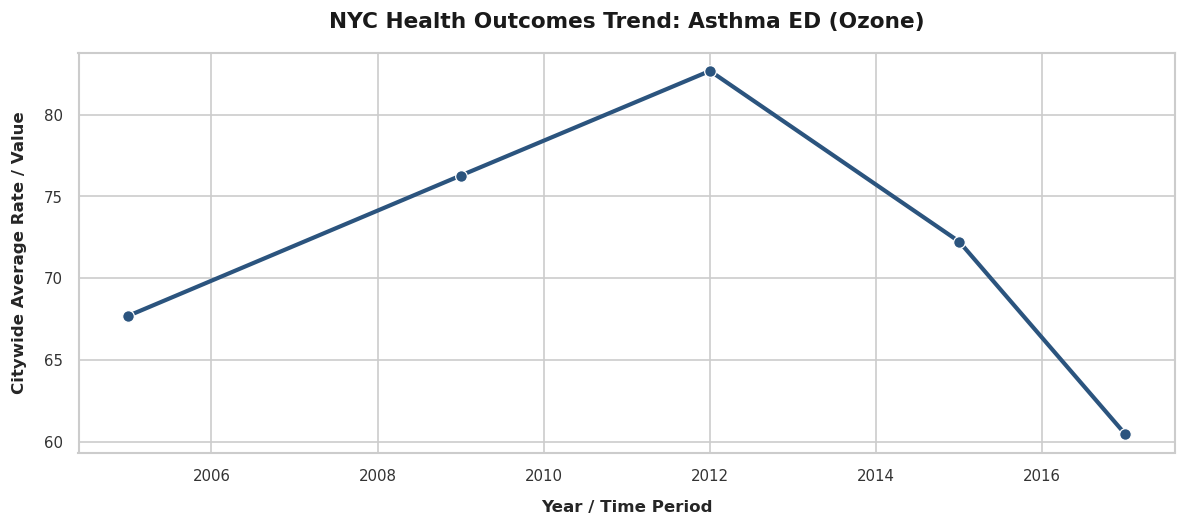

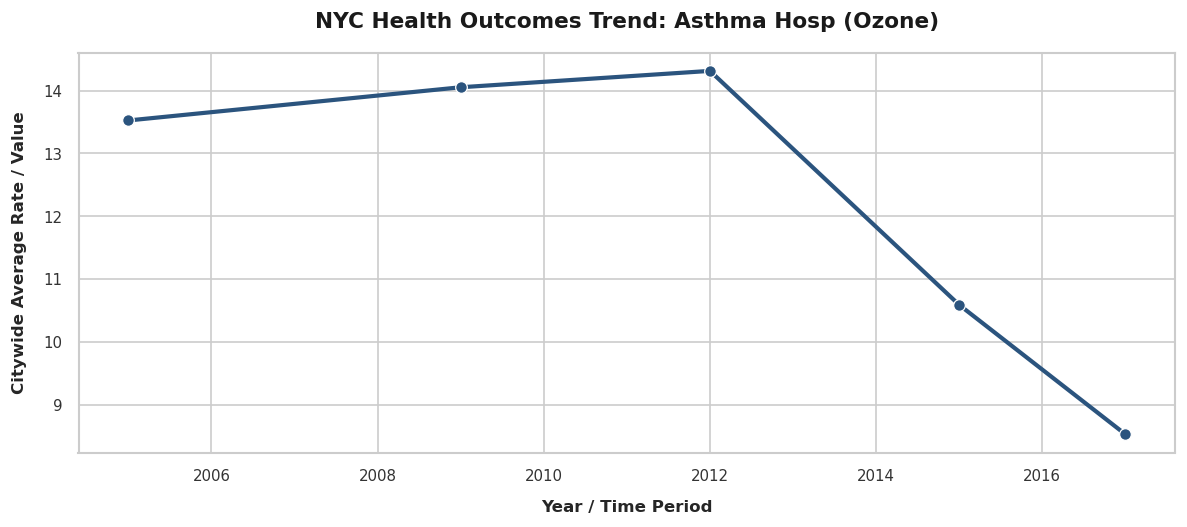

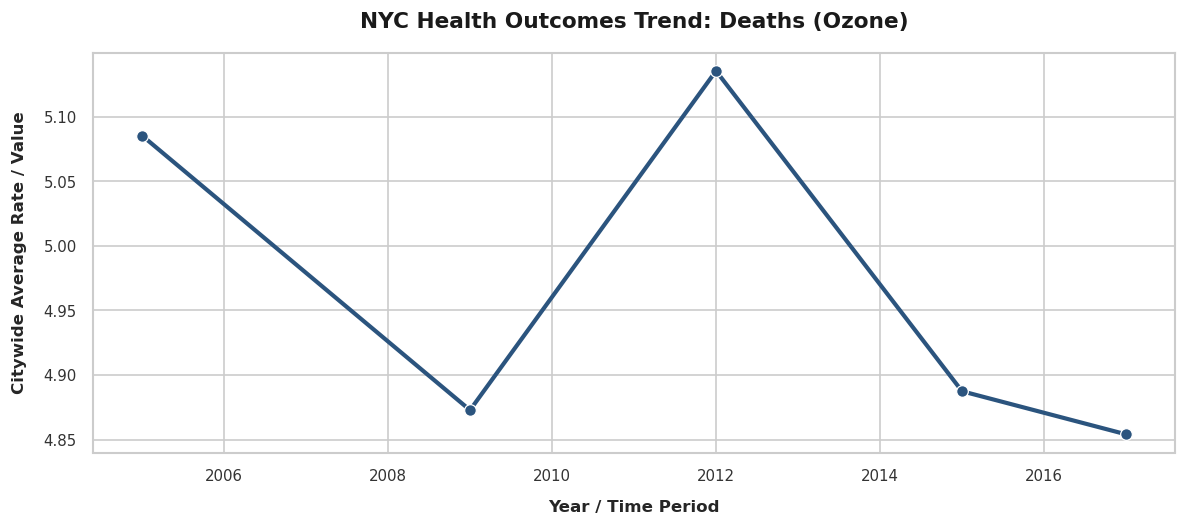

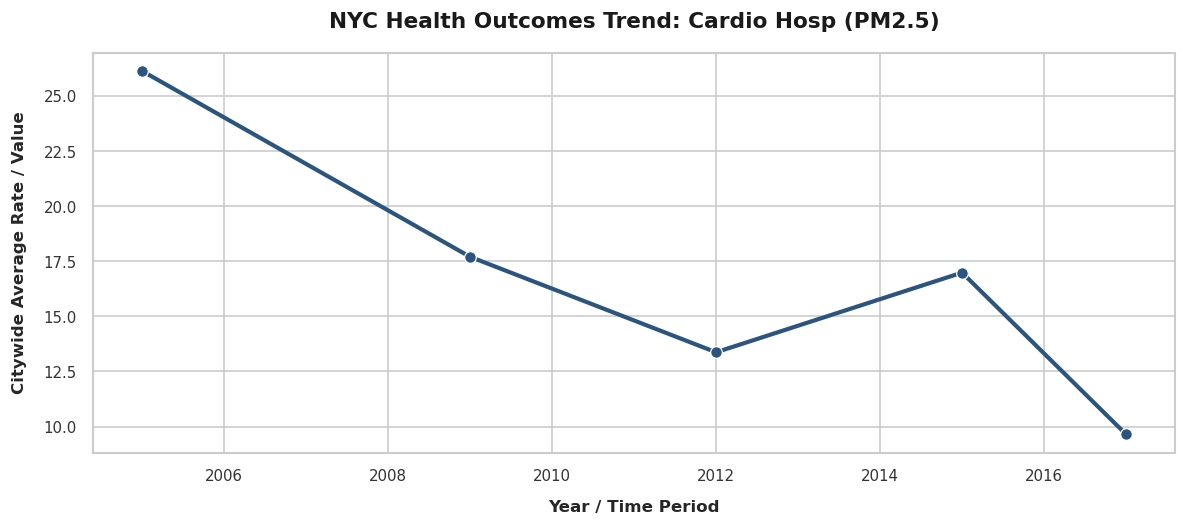

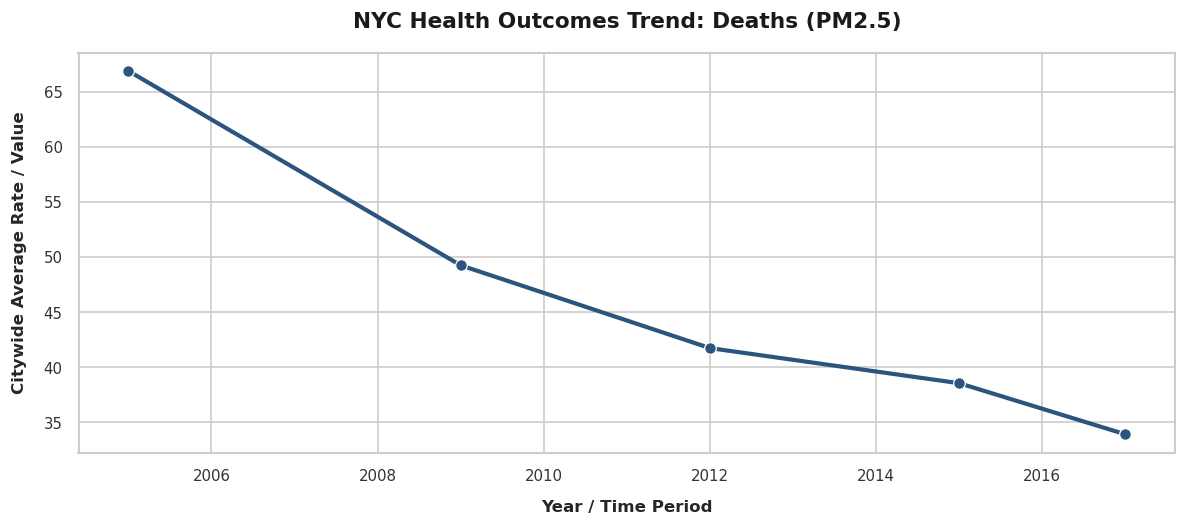

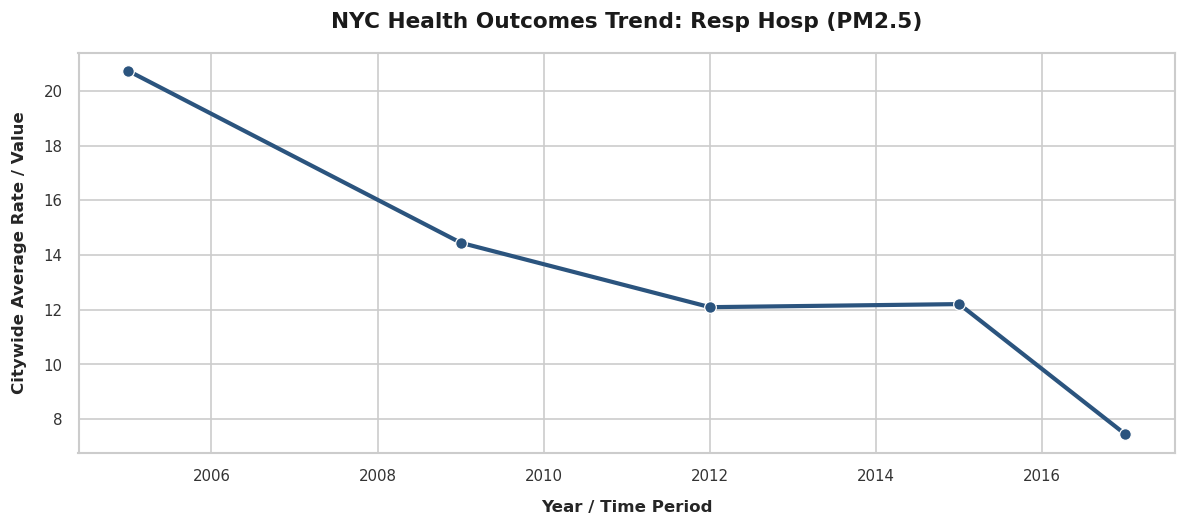

In [9]:
# Health trends over time


def extract_year(val):
    val_str = str(val)
    # Find all 4-digit years in the text string
    years = re.findall(r"(?:19|20)\d{2}", val_str)
    if years:
        return int(years[0])  # Take the starting year of the period
    return None


#variables
health_indicators = [
    "Asthma ED (PM2.5)",
    "Asthma ED (Ozone)",
    "Asthma Hosp (Ozone)",
    "Deaths (Ozone)",
    "Cardio Hosp (PM2.5)",
    "Deaths (PM2.5)",
    "Resp Hosp (PM2.5)",
]

for health_metric in health_indicators:
    name_col = "Name" if "Name" in clean_df.columns else "Indicator Name"
    sub_df = clean_df[clean_df[name_col] == health_metric].copy()

    if sub_df.empty:
        print(f"Metric '{health_metric}' not found in DataFrame.")
        continue

    # Locate the time period column
    time_col = next(
        (
            col
            for col in ["Time Period", "Time", "Year", "Period"]
            if col in sub_df.columns
        ),
        None,
    )
    if time_col is None:
        continue

    # Detect value column dynamically
    val_col = next(
        (
            col
            for col in [
                "Data Value",
                "Value",
                "Estimated Annual Rate per 100,000",
                "Mean",
            ]
            if col in sub_df.columns
        ),
        None,
    )
    if val_col is None:
        continue

    parsed_data = []
    for _, row in sub_df.iterrows():
        y = extract_year(row[time_col])
        if y is not None:
            try:
                val = float(row[val_col])
                parsed_data.append({"Year": y, "Value": val})
            except (ValueError, TypeError):
                continue

    plot_df = pd.DataFrame(parsed_data)

    if not plot_df.empty:
        # Average across neighborhoods to get the citywide trend per year
        plot_df = plot_df.groupby("Year")["Value"].mean().reset_index()
        plot_df = plot_df.sort_values("Year")

        plt.figure(figsize=(10, 4.5), dpi=120)
        sns.set_theme(style="whitegrid", font_scale=0.85)

        ax = sns.lineplot(
            data=plot_df,
            x="Year",
            y="Value",
            color="#2B547E",
            marker="o",
            linewidth=2.5,
            markersize=7,
        )

        plt.title(
            f"NYC Health Outcomes Trend: {health_metric}",
            fontsize=13,
            fontweight="bold",
            pad=15,
            color="#1A1A1A",
            loc="center",
        )
        plt.xlabel("Year / Time Period", fontsize=10, fontweight="bold", labelpad=10)
        plt.ylabel("Citywide Average Rate / Value", fontsize=10, fontweight="bold", labelpad=10)

        plt.xticks(fontsize=9, color="#333333")
        plt.yticks(fontsize=9, color="#333333")

        plt.tight_layout()
        plt.show()